In [1]:
import numpy as np
import pandas as pd
import h5py
import vaex
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path

from astropy import units as u
from astropy.io import ascii, fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord,CartesianRepresentation,match_coordinates_sky

import functions as fn 

np.random.seed(0)

In [2]:
box = 'r' # the boxes are 'rogue', 'elektra' 'storm' and 'MM' (for Marvelous Massive)
num = 741 # number of our galaxy within the box
D = 2000 # 2000 kpc is 2 Mpc
mlim_str = '26p5' # 26.5 is the depth of the yr 10 survey, i had to do p instead of . because ananke got mad at there being a decimal in the name of one of the galaxies. weird
name = f'{box}_4096_{num}_data_{D}_{mlim_str}' 

# this is the path to the galaxy, change this to be where you put your data! I used an f-string and some {} to put my variables in here so it is easy to read in different catalogs
dwarfcatpath = f"/home/otteleno/MAP/matched_filter_starters/{box}_{num}_data/r741/survey.MM_r741_data_2000_25.0.h5" 
vdwarfcat = vaex.open(dwarfcatpath)
dwarfcat = pd.DataFrame(vdwarfcat,columns=vdwarfcat.column_names)




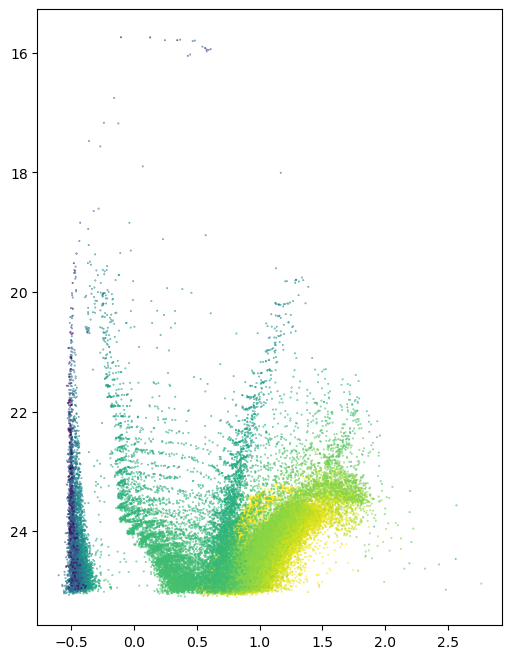

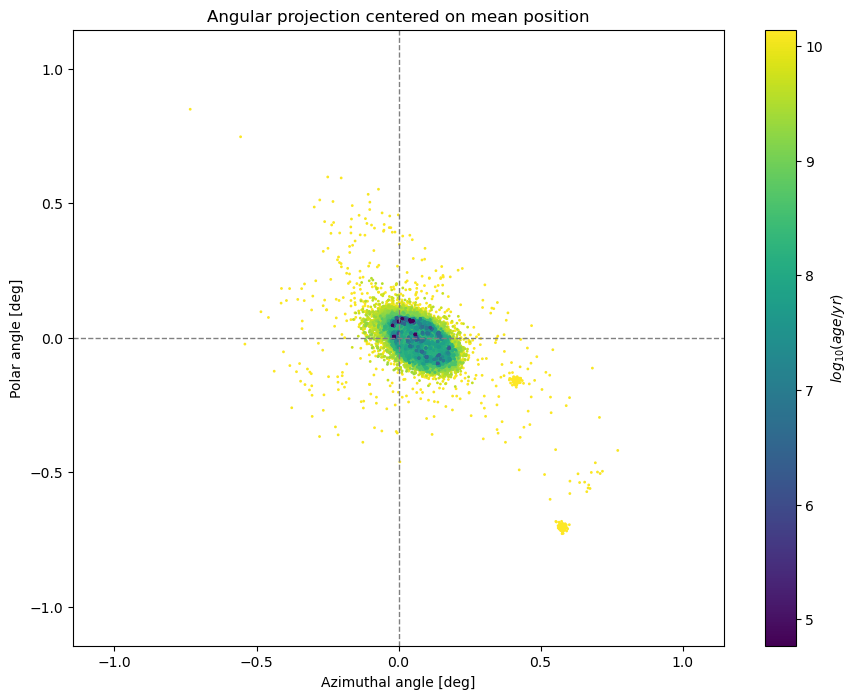

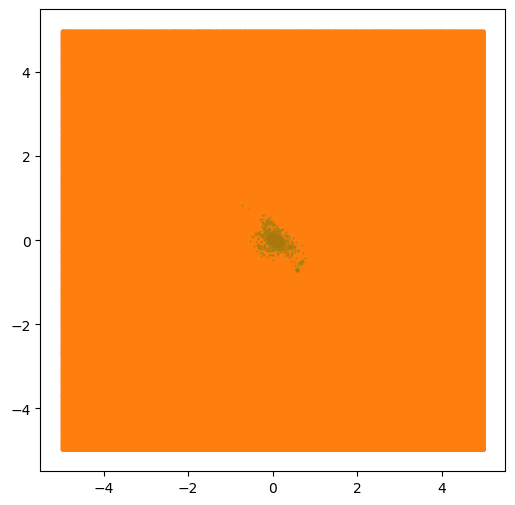

Saving ... 


In [3]:
size_kpc = 40 # length of one edge of the plot in kpc - edge length of the plots based on the first plot in this notebook
pdist = (size_kpc/D) * (180/np.pi) # converting the above into degrees (on the sky) instead of kpc
year = 10
mlim = '25'
c1='px'
c2='py'
edgelength = 10 # size of the bg field that I generated, this is (unecessarily) huge, so if you want a smaller one I can make one 
plotdir = f'{box}_4096_{num}' # folder where you want your plots to go if you are saving them
bgcatpath = f"/home/otteleno/MAP/matched_filter_starters/bgcats/bgr{mlim}g{mlim}_for_mf_{int(edgelength)}deg.fits"
table_final = fn.bg_dwarf_combo(pdist,name,year,D,c1,c2,plotdir,dwarfcatpath,bgcatpath,edgelength,plot=True,save=True) 

## Matched filter detection

We have reached our destination of using the matched filter. Again, a function for this has been defined, but I reccomend reading through that script (after or during when you read the paper I sent [here](https://iopscience.iop.org/article/10.1086/340957/pdf)) to understand how this works. It is hard to parse, but with practice and time you will become an expert. 

In [4]:
gal_name = f"{box}_{num}"

Total number of signal CMD
1.0
Total number of stars in background CMD
301.69546909930347
x min  -68.75493541569878
x max  68.75493541569878
y min  -68.75493541569878
y max  68.75493541569878
Sigma in smoothed stellar counts 2.28114584686464
Mean in smoothed stellar counts -0.004074605163549478


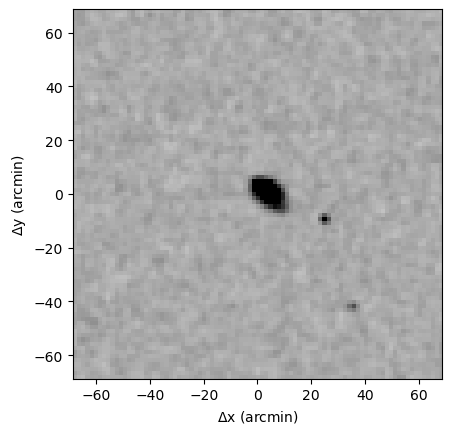

In [5]:
age = '10'
mh = '-2'

from matched_filter_ani import matched_filter_ani as mf

iso_info = 'parsec' # there are a lot of isochone models out there, parsec is the one I like to use
rmaglim=26

# the number of pixels (bins in ra/dec on the sky) is the thing that slows this code down the most (look at the nested loop in the matched fitler function to see why)
# i paramaterize this function based on number of pixels instead of the size of the pixel itself so I have a better idea of how long it should take to run
# 2000-3000 works best for the close + deep images or those with big features, closer to 1000 is better for the distant and shallow ones. 
# this is because each bin on the sky needs enough real stars to get weighted highly, and when the galaxy is far or the observations are shallow, we detect fewer stars
numpix = 8000
pix = (np.round(np.sqrt((2*pdist*60)**2 / numpix),2))
catalog=f'/home/otteleno/MAP/matched_filter_testing/catalogs/' + name + f'_{c1}{c2}_formf_bg{edgelength}deg.fits'
field = name+f'_mfmag{rmaglim}_{iso_info}{age}{mh}{c1}{c2}_{np.round(pdist*60,0)}'

mf(gal_name, plotdir=f"../plots/{plotdir}/", # directory to save the plots to. 
    field=field, # this is what you want the final image to be named if you save it 
    catalog=catalog, # this is the directory to the table you made that contains the simulated stars in the galaxy and the background sources
    signal_file=f"/home/otteleno/MAP/matched_filter_starters/signal_files/{iso_info}_{D}_{age}{mh}_signal_cmd_gr.txt",
    plot=False, rmaglim = rmaglim, pix=pix, pdist=pdist*60) 


# this will take a few minutes to run, especially in the notebook format. On my machine, it took about 10 minutes, and I am using a remote machine much more powerful than my laptop
# I recommend runnning the function in the terminal for actual research purposes - speeds things up and is easier to iterate if you change the functions
# the runtime will vary as well based on the number of pixels you choose to use and other knobs you may want to turn 